In [1]:
import sys 
sys.path.append('..')
import jax
from functools import partial
from jax import grad, jacfwd, vmap, jit, hessian, value_and_grad, lax
from jax.lax import scan
import jax.numpy as jnp
import numpy as np
from scipy.special import comb
from ergodic_planning.ergodic_metric import ErgodicMetric # 计算遍历度指标
# 增广拉格朗日法优化器
from ergodic_planning.solver import al_iLQR 
from ergodic_planning.augument_lagrange_func import loss_traj_single, eq_constr, ineq_constr_single, loss_compare_single
import yaml
import pickle as pkl
import copy

import os
from openpyxl import Workbook, load_workbook
import logging

logging.basicConfig(
    filename='log/app.log',          # 日志文件名
    level=logging.INFO,          # 日志等级
    format='%(asctime)s [%(levelname)s] %(message)s',  # 格式
)
from experiment.config import (
    opt_args,
    target_distr,
    robot_distr,
    workspace_size,
    robot_number,
    init_state_old,
    sol_trajs_old,
    robot_model_single,
)
init_state = init_state_old
sol_trajs = sol_trajs_old
robot_number = opt_args["robot_number"]
tsteps = opt_args["tsteps"]

# 更高效的方法 - 使用列表推导式
F_beta = jnp.full(tsteps, 1)
n_small_betas = jnp.array([jnp.array([])] * robot_number)
F_beta_normalized = F_beta / jnp.sum(F_beta)  # 预先计算归一化值

# 使用列表推导式创建 betas
betas = [
    {
    'x': jnp.asarray(F_beta_normalized),
    'px': jnp.asarray(n_small_betas),
}
    for _ in range(robot_number)
]

# 双机器人初始化
start_pos = opt_args["x0"]
end_pos = opt_args["xf"]
# 假设你想创建包含 n 个 al_iLQR 结果的数组
n = robot_number  # 例如，创建 10 个结果
traj_solver = [al_iLQR(
    args=opt_args,
    objective=loss_traj_single,
    dynamics=robot_model_single,
    inequality=ineq_constr_single,
    equality=eq_constr,
    target_distr = robot_distr[_id].evals,
    robot_id = _id,
) for _id in range(n)]

for robot_id in range(n):
    sol_trajs[robot_id], conv = traj_solver[robot_id].solve(
        x0=init_state[robot_id],
        init_sol=sol_trajs[robot_id],
        beta=betas[robot_id],
        init_dual=True,
        max_iter=1,
        if_print=False,
    ) 

decay_type = 'nodecay'
from utils.plot_utils import plot_trajs_old, plot_line_graph
from ergodic_planning.tools import exchange_info_old, optimize_trajs, update_accumulated_time
from ergodic_planning.decay_utils import update_beta_single
from IPython.display import clear_output
itera = 5
kk = 0
init_dual = False
save_path = '../figures/baseline.png'

involved_robots = list(range(robot_number))
involved_robots = set(involved_robots)
accumulated_time = 0
be_num = 1
global_metric = {
        'time': [],
        'values': [],
}
point_set = jnp.vstack(target_distr._dist_params['means'])
connect_timestep = None
robot_pair = []


satisfy constraint, but not converge, id: 0 and r_penalty: 1.000000 and violations:0.000000:
satisfy constraint, but not converge, id: 1 and r_penalty: 1.000000 and violations:0.000000:
satisfy constraint, but not converge, id: 2 and r_penalty: 1.000000 and violations:0.000000:
satisfy constraint, but not converge, id: 3 and r_penalty: 1.000000 and violations:0.000000:


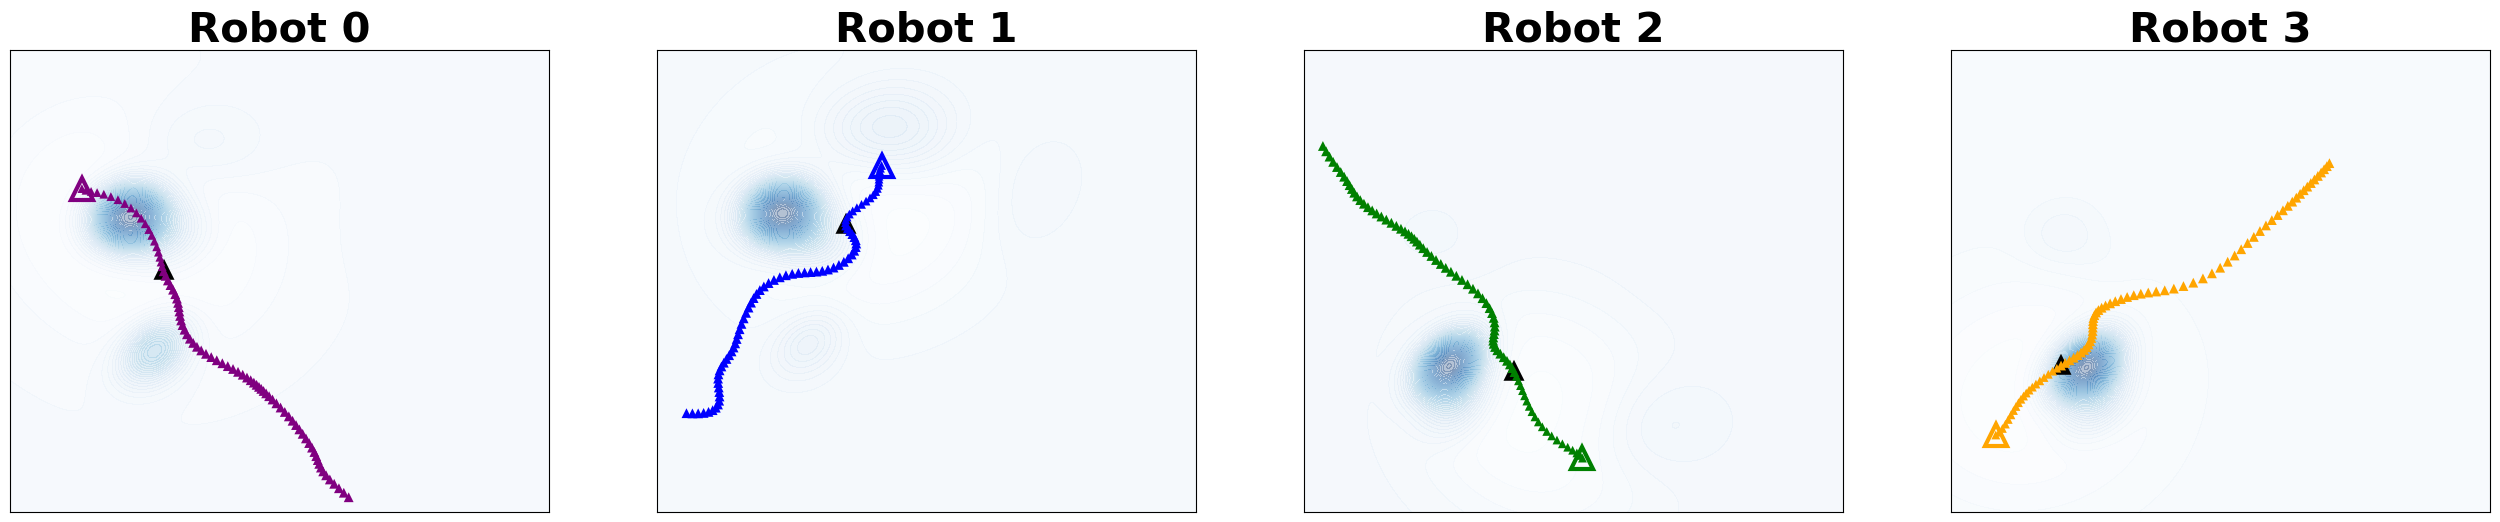

iter 12 1.0
iter 7 1.0
iter 0 1.0



KeyboardInterrupt



In [2]:
while kk < itera:
    sol_trajs, to_remove = optimize_trajs(involved_robots, sol_trajs, betas, traj_solver, init_state, init_dual)
    involved_robots -= to_remove
        
    clear_output(wait=True)                   # 清除上一次输出，动态刷新
    init_dual = False
    # logging.info(f"Complete the iteration {kk+1}")
    kk += 1
    if not involved_robots or kk == itera - 1:
        updated_robots = []
        candidate_indices = jnp.array([], dtype=jnp.int32)
        global_metric['time'].append(len(global_metric['time']))
        global_metric['values'].append(loss_compare_single(sol_trajs, target_distr.evals))   
            
        connect_timestep, accumulated_time = update_accumulated_time(connect_timestep, accumulated_time, be_num)
        if connect_timestep >= 4:
            accumulated_time -= (connect_timestep - 4)
            if accumulated_time >= tsteps - 4:
                break
            connect_timestep = 4
            for r_id in range(robot_number):
                # print(f"connect_timestep = {connect_timestesp}, type = {type(connect_timestep)}")
                u_t = sol_trajs[r_id]['x'][connect_timestep, 0:2]
                robot_distr[r_id].bayes_filter_reset(target_distr.evals[0], u_t)
                traj_solver[r_id].update_distribution(robot_distr[r_id].evals)
        
        if accumulated_time == 10 * be_num:
            if accumulated_time >= tsteps - 4:
                break
            logging.info("update map")
            target_distr.update_map(accumulated_time, "perturb", 'write')
            # target_distr.update_map(accumulated_time, "perturb", 'read')
            point_set = jnp.vstack(target_distr._dist_params['means'])
            be_num += 1

        sol_trajs, connected_pairs = exchange_info_old(sol_trajs, robot_pair, connect_timestep, robot_distr)
        betas = update_beta_single(sol_trajs, betas, decay_type)
        involved_robots = set(list(range(robot_number)))
        
        init_state = [traj['x'][0, :] for traj in sol_trajs]  
        init_dual = True
        kk = 0
        logging.info(f"connect time:{connect_timestep}, accumulated time:{accumulated_time}, and the robot pair:{robot_pair}")
        connect_timestep = None
    plot_trajs_old(start_pos, end_pos, sol_trajs, betas, False, robot_distr, save_path)
# plot_trajs_old(start_pos, end_pos, sol_trajs, betas, True, robot_distr, save_path)  

In [ ]:
from utils.data_collect import save_ergodic_metrics_to_excel
save_ergodic_metrics_to_excel(robot_number, global_metric, "no_exchange_info")